In [37]:
import os
import numpy as np
import scipy.io as sio
from scipy.signal import find_peaks
from scipy import stats
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path



In [44]:
# PARAMETERS
subject = "sub-racsleep04b"
base_dir = "/home/vob3"
data_root = f"/orcd/data/ldlewis/001/om/hf303/for_ore/{subject}"
TR = 2.22
window = (-15, 20)
baseline_window = (-15, -10)


In [45]:
signal_sets = {
    "with_reg": ["GM_PSC", "Thalamus_PSC", "D2_with_reg_PSC", "D1_with_reg_PSC", "Norepinephrine_with_reg"],
    "without_reg": ["GM_PSC", "Thalamus_PSC", "D2_without_reg_PSC", "D1_without_reg_PSC", "Norepinephrine_without_reg"]
}

signal_colors = {
    "GM_PSC": "black",
    "Thalamus_PSC": "purple",
    "D2_with_reg_PSC": "green",
    "D1_with_reg_PSC": "orange",
    "Norepinephrine_with_reg": "teal",
}

pretty_names = {
    "GM_PSC": "GM",
    "Thalamus_PSC": "Thalamus",
    "D2_with_reg_PSC": "D2",
    "D1_with_reg_PSC": "D1",
    "Norepinephrine_with_reg": "NE",
}



In [46]:
# eeg metrics
metrics = sio.loadmat(os.path.join(data_root, "eeg", "metrics.mat"),
                      squeeze_me=True, struct_as_record=False)
eeg_struct = metrics["eeg"]

eeg_t = np.squeeze(eeg_struct.t_clean)
ratio = np.squeeze(eeg_struct.alpha_delta_clean)

dt = np.median(np.diff(eeg_t))
even_t = np.arange(eeg_t[0], eeg_t[-1], dt)
ratio_interp = np.interp(even_t, eeg_t, ratio)


def moving_average(x, w):
    return np.convolve(x, np.ones(w), 'same') / w

window_s = int(50 / dt)
ratio_smooth = moving_average(ratio_interp, window_s)
ratio_z = (ratio_smooth - np.mean(ratio_smooth)) / np.std(ratio_smooth)

inv = -ratio_z
peaks, props = find_peaks(inv, prominence=1.2, height=0.5, distance=int(8 / dt))
eeg_arousals = even_t[peaks]
print(f"Detected {len(eeg_arousals)} EEG-based arousals.")


Detected 1 EEG-based arousals.


In [47]:
# load fmri signals

csv_path = Path(base_dir) /f"{subject}"/ f"{subject}_bold_timeseries.csv"
csv_df = pd.read_csv(csv_path)


FileNotFoundError: [Errno 2] No such file or directory: '/home/vob3/sub-racsleep09/sub-racsleep09_bold_timeseries.csv'

In [42]:
def extract_peri_with_baseline(signal, events, window, TR, baseline_window=(-15, -10)):
    peri = []
    n_before = round(abs(window[0]) / TR)
    n_after = round(window[1] / TR)
    time_axis = np.linspace(window[0], window[1], n_before + n_after)
    for t in events:
        idx = int(t / TR)
        start = idx - n_before
        end = idx + n_after
        if start >= 0 and end <= len(signal):
            chunk = signal[start:end]
            baseline_mask = (time_axis >= baseline_window[0]) & (time_axis <= baseline_window[1])
            baseline = np.mean(chunk[baseline_mask])
            peri.append(chunk - baseline)
    return np.vstack(peri) if len(peri) > 0 else np.empty((0, n_before + n_after))


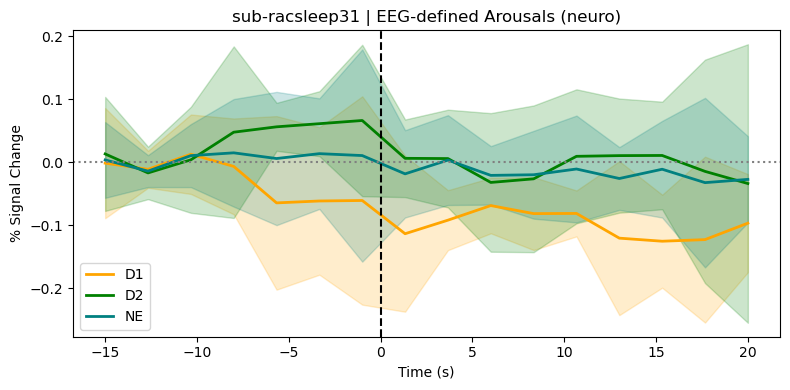

✅ Saved /home/vob3/sub-racsleep31_EEG_arousal_neuro_with_reg.png


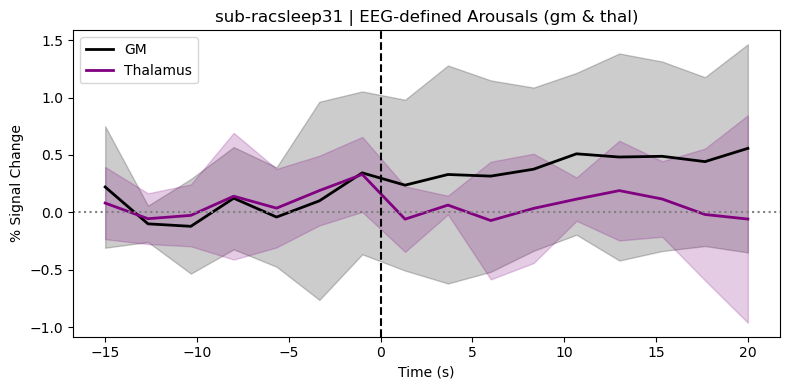

✅ Saved /home/vob3/sub-racsleep31_EEG_arousal_gm_thal_with_reg.png


In [43]:
neuro_signals = ["D1_with_reg_PSC", "D2_with_reg_PSC", "Norepinephrine_with_reg"]
gm_thal_signals = ["GM_PSC", "Thalamus_PSC"]

signal_groups = {
    "neuro": neuro_signals,
    "gm_thal": gm_thal_signals
}

# plot
for group_name, signal_list in signal_groups.items():
    fig, ax = plt.subplots(figsize=(8, 4))
    for signal_name in signal_list:
        if signal_name not in csv_df.columns:
            print(f"Skipping missing column: {signal_name}")
            continue
        signal_data = csv_df[signal_name].values
        peri = extract_peri_with_baseline(signal_data, eeg_arousals, window, TR, baseline_window)
        if peri.shape[0] == 0:
            print(f"No valid peri-event data for {signal_name}")
            continue

        time_axis = np.linspace(window[0], window[1], peri.shape[1])
        mean = np.mean(peri, axis=0)
        sem = np.std(peri, axis=0, ddof=1) / np.sqrt(peri.shape[0])
        ci95 = stats.t.ppf(0.975, peri.shape[0]-1) * sem

        ax.plot(time_axis, mean, color=signal_colors[signal_name], label=pretty_names[signal_name], linewidth=2)
        ax.fill_between(time_axis, mean - ci95, mean + ci95,
                        color=signal_colors[signal_name], alpha=0.2)

    ax.axvline(0, color="black", linestyle="--")
    ax.axhline(0, color="gray", linestyle=":")
    ax.set_xlabel("Time (s)")
    ax.set_ylabel("% Signal Change")
    ax.legend()
    ax.set_title(f"{subject} | EEG-defined Arousals ({group_name.replace('_', ' & ')})")

    plt.tight_layout()
    save_path = Path(base_dir) / f"{subject}_EEG_arousal_{group_name}_with_reg.png"
    fig.savefig(save_path, dpi=150)
    #plt.close(fig)
    plt.show()
    print(f"✅ Saved {save_path}")


